In [31]:
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc
import os


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

2025-12-01 10:58:59 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-12-01 10:58:59 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table missing; error code 0x90)
2025-12-01 10:58:59 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/SFIndia.ttc: Can not load face (SFNT font table missing; error code 0x8e)
2025-12-01 10:58:59 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str
2025-12-01 10:58:59 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel

In [32]:
import glob
from pycocotools.coco import COCO

BASE_JSON = COCO("./data/COCO_Football Pixel.json")

IMAGE_NAME_LIST = sorted(os.listdir("./data/images/"))
IMAGE_PATH_LIST = sorted(glob.glob(f"./data/images/*"))

loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


In [33]:
IMAGE_PATH_LIST

['./data/images/Frame 1  (1).jpg',
 './data/images/Frame 1  (1).jpg___fuse.png',
 './data/images/Frame 1  (1).jpg___save.png',
 './data/images/Frame 1  (10).jpg',
 './data/images/Frame 1  (10).jpg___fuse.png',
 './data/images/Frame 1  (10).jpg___save.png',
 './data/images/Frame 1  (100).jpg',
 './data/images/Frame 1  (100).jpg___fuse.png',
 './data/images/Frame 1  (100).jpg___save.png',
 './data/images/Frame 1  (11).jpg',
 './data/images/Frame 1  (11).jpg___fuse.png',
 './data/images/Frame 1  (11).jpg___save.png',
 './data/images/Frame 1  (12).jpg',
 './data/images/Frame 1  (12).jpg___fuse.png',
 './data/images/Frame 1  (12).jpg___save.png',
 './data/images/Frame 1  (13).jpg',
 './data/images/Frame 1  (13).jpg___fuse.png',
 './data/images/Frame 1  (13).jpg___save.png',
 './data/images/Frame 1  (14).jpg',
 './data/images/Frame 1  (14).jpg___fuse.png',
 './data/images/Frame 1  (14).jpg___save.png',
 './data/images/Frame 1  (15).jpg',
 './data/images/Frame 1  (15).jpg___fuse.png',
 './dat

In [34]:
print("[누락 파일 점검]")

tmp_list, err_list = [], []

for name in IMAGE_NAME_LIST:
    tmp_list.append(int(name.split("(")[-1].split(")")[0]))

for i in range(100):
    tmp_count = tmp_list.count(i+1)
    if tmp_count != 3:
        err_list.append(i)

print(f"누락 파일: {err_list if len(err_list) != 0 else '0개'}")

[누락 파일 점검]
누락 파일: 0개


In [35]:
NORM_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith(".jpg")]
FUSE_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith("fuse.png")]
SAVE_PATH_LIST = [x for x in IMAGE_PATH_LIST if x.endswith("save.png")]

NORM_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith(".jpg")]
FUSE_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith("fuse.png")]
SAVE_NAME_LIST = [x for x in IMAGE_NAME_LIST if x.endswith("save.png")]

In [36]:
print(f"[사이즈 정보]")

import random
import torchvision

rand_idx = random.randint(1, len(NORM_PATH_LIST))

sample_norm_image = torchvision.io.read_image(NORM_PATH_LIST[rand_idx])
sample_fuse_image = torchvision.io.read_image(FUSE_PATH_LIST[rand_idx])
sample_save_image = torchvision.io.read_image(SAVE_PATH_LIST[rand_idx])

print(f"· 원본 이미지: {sample_norm_image.shape}")
print(f"· fuse 이미지: {sample_fuse_image.shape}")
print(f"· save 이미지: {sample_save_image.shape}")

[사이즈 정보]
· 원본 이미지: torch.Size([3, 1080, 1920])
· fuse 이미지: torch.Size([4, 1080, 1920])
· save 이미지: torch.Size([4, 1080, 1920])


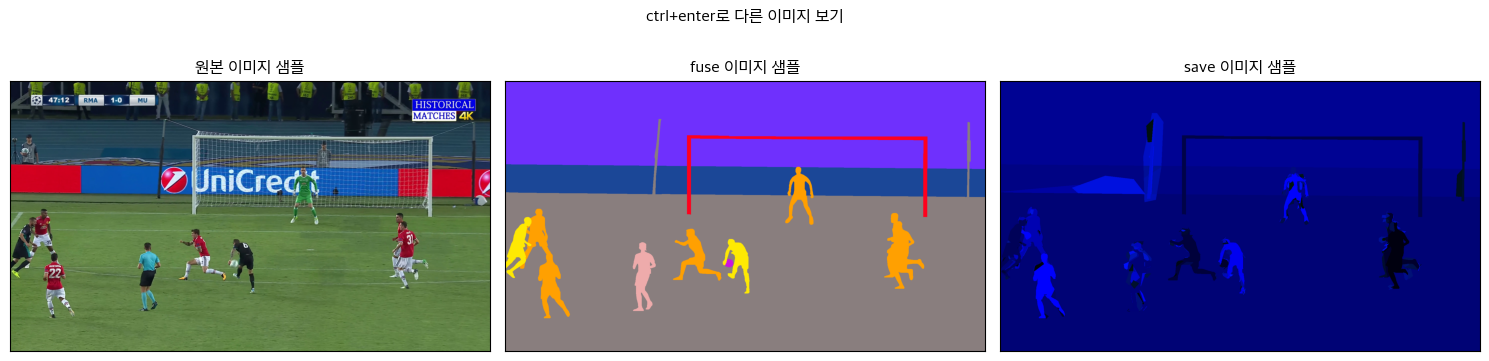

In [37]:
# 샘플 이미지 출력

# 축 숫자 표기 제거 함수 생성
def remove_ticks(columns=2):
    for num in range(columns):
        axes[num].set_xticks([])
        axes[num].set_yticks([])


rand_idx = random.randint(1, len(NORM_PATH_LIST))

sample_norm_image = torchvision.io.read_image(NORM_PATH_LIST[rand_idx]).permute(1, 2, 0)
sample_fuse_image = torchvision.io.read_image(FUSE_PATH_LIST[rand_idx])[:3, :, :].permute(1, 2, 0)
sample_save_image = torchvision.io.read_image(SAVE_PATH_LIST[rand_idx])[:3, :, :].permute(1, 2, 0)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(sample_norm_image)
axes[1].imshow(sample_fuse_image)
axes[2].imshow(sample_save_image)

fig.suptitle("ctrl+enter로 다른 이미지 보기")
axes[0].set_title("원본 이미지 샘플")
axes[1].set_title("fuse 이미지 샘플")
axes[2].set_title("save 이미지 샘플")

remove_ticks(3)
plt.tight_layout()
plt.show()

In [38]:
print("[클래스 종류]")

category_set = set()

img_ids = BASE_JSON.getImgIds()

for img_id in img_ids:
    ann_ids = BASE_JSON.getAnnIds(img_id)
    for ann_id in ann_ids:
        anns = BASE_JSON.loadAnns(ann_id)
        for ann in anns:
            category_set.add(ann["category_id"])

print(f"· 총 {len(category_set)} 종류: {category_set}")


img_id = random.randint(1, len(BASE_JSON.getImgIds()))
ann_ids = BASE_JSON.getAnnIds(img_id)

print(f"\n[json 샘플 데이터 (img_id: {img_id})]")

for ann_id in ann_ids:
    anns = BASE_JSON.loadAnns(ann_id)
    for ann in anns:
        for key, value in ann.items():
            print(f"· {key}:  {value}")
        print("")

[클래스 종류]
· 총 10 종류: {1392800, 1392801, 1392802, 1393250, 1392804, 1392805, 1392806, 1392807, 1392794, 1392799}

[json 샘플 데이터 (img_id: 61)]
· id:  534
· image_id:  61
· segmentation:  [[1472, 231, 1471, 232, 1470, 233, 1469, 234, 1468, 234, 1467, 234, 1466, 234, 1465, 234, 1464, 234, 1463, 234, 1462, 235, 1461, 235, 1460, 235, 1459, 235, 1458, 235, 1457, 236, 1456, 236, 1455, 237, 1454, 238, 1453, 238, 1452, 238, 1451, 238, 1450, 238, 1449, 238, 1448, 238, 1447, 238, 1446, 238, 1445, 238, 1444, 238, 1443, 238, 1442, 238, 1441, 238, 1440, 238, 1439, 238, 1438, 238, 1437, 239, 1436, 240, 1435, 240, 1434, 241, 1433, 241, 1432, 242, 1432, 243, 1431, 244, 1430, 245, 1429, 246, 1428, 247, 1427, 248, 1426, 249, 1425, 250, 1424, 251, 1423, 252, 1422, 253, 1421, 254, 1420, 255, 1419, 256, 1418, 257, 1417, 258, 1416, 259, 1416, 260, 1415, 261, 1414, 262, 1413, 263, 1412, 264, 1412, 265, 1411, 266, 1410, 267, 1409, 268, 1409, 269, 1408, 270, 1408, 271, 1407, 272, 1407, 273, 1406, 274, 1406, 275, 1

## 실험 설계

1. json 데이터로만 학습

2. save 이미지로 학습

3. fuse 이미지로 학습

In [ ]:
import torch.nn as nn
import torchvision.transforms as transforms

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

		# Convolution, Batch Normalization, ReLU 연산을 합친 함수
        def CBR2d(input_channel, output_channel, kernel_size=3, stride=1):
            layer = nn.Sequential(
                nn.Conv2d(input_channel, output_channel, kernel_size=kernel_size, stride=stride),
                nn.BatchNorm2d(num_features=output_channel),
                nn.ReLU()
            )
            return layer

		# Contracting path
        # 572x572x1 => 568x568x64
        self.conv1 = nn.Sequential(
            CBR2d(1, 64, 3, 1),
            CBR2d(64, 64, 3, 1)
        )
		# 568x568x64 => 284x284x64 		
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)


		# 284x284x64 => 280x280x128
        self.conv2 = nn.Sequential(
            CBR2d(64, 128, 3, 1),
            CBR2d(128, 128, 3, 1)
        )
		# 280x280x128 => 140x140x128
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


		# 140x140x128 => 136x136x256
        self.conv3 = nn.Sequential(
            CBR2d(128, 256, 3, 1),
            CBR2d(256, 256, 3, 1)
        )
		# 136x136x256 => 68x68x256
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)


		# 68x68x256 => 64x64x512
        # Contracting path 마지막에 Dropout 적용
        self.conv4 = nn.Sequential(
            CBR2d(256, 512, 3, 1),
            CBR2d(512, 512, 3, 1),
            nn.Dropout(p=0.5)
        )
		# 64x64x512 => 32x32x512
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
		# Contracting path 끝
        
		
        # Bottlneck 구간
        # 32x32x512 => 28x28x1024
        self.bottleNeck = nn.Sequential(
            CBR2d(512, 1024, 3, 1),
            CBR2d(1024, 1024, 3, 1),
        )
		# Bottlneck 구간 끝


		# Expanding path
        # channel 수를 감소 시키며 Up-Convolution
		# 28x28x1024 => 56x56x512        
        self.upconv1 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=2, stride=2)


		# Up-Convolution 이후 channel = 512
        # Contracting path 중 같은 단계의 Feature map을 가져와 Up-Convolution 결과의 Feature map과 Concat 연산
        # => channel = 1024 가 됩니다.
        # forward 부분을 참고해주세요
        # 56x56x1024 => 52x52x512
        self.ex_conv1 = nn.Sequential(
            CBR2d(1024, 512, 3, 1),
            CBR2d(512, 512, 3, 1)
        )

		# 52x52x512 => 104x104x256
        self.upconv2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)

		# 104x104x512 => 100x100x256
        self.ex_conv2 = nn.Sequential(
            CBR2d(512, 256, 3, 1),
            CBR2d(256, 256, 3, 1)
        )

		# 100x100x256 => 200x200x128
        self.upconv3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)

		# 200x200x256 => 196x196x128
        self.ex_conv3 = nn.Sequential(
            CBR2d(256, 128, 3, 1),
            CBR2d(128, 128, 3, 1)
        )

		# 196x196x128 => 392x392x64
        self.upconv4 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)

		# 392x392x128 => 388x388x64
        self.ex_conv4 = nn.Sequential(
            CBR2d(128, 64, 3, 1),
            CBR2d(64, 64, 3, 1),
        )

		# 논문 구조상 output = 2 channel
	    # train 데이터에서 세포 / 배경을 검출하는것이 목표여서 class_num = 1로 지정
		# 388x388x64 => 388x388x1
        self.fc = nn.Conv2d(64, 1, kernel_size=1, stride=1)


    def forward(self, x):
    	# Contracting path
        # 572x572x1 => 568x568x64
        layer1 = self.conv1(x)
        
        # Max Pooling
        # 568x568x64 => 284x284x64
        out = self.pool1(layer1)

		# 284x284x64 => 280x280x128
        layer2 = self.conv2(out)
        
        # Max Pooling
        # 280x280x128 => 140x140x128
        out = self.pool2(layer2)

		# 140x140x128 => 136x136x256
        layer3 = self.conv3(out)
        
        # Max Pooling
        # 136x136x256 => 68x68x256
        out = self.pool3(layer3)

		# 68x68x256 => 64x64x512
        layer4 = self.conv4(out)
        
        # Max Pooling
        # 64x64x512 => 32x32x512
        out = self.pool4(layer4)

		# bottleneck 
        # 32x32x512 => 28x28x1024
        bottleNeck = self.bottleNeck(out)

		# Expanding path
        # 28x28x1024 => 56x56x512
        upconv1 = self.upconv1(bottleNeck)
        
        # Contracting path 중 같은 단계의 Feature map을 가져와 합침
        # Up-Convolution 결과의 Feature map size 만큼 CenterCrop 하여 Concat 연산
        # 56x56x512 => 56x56x1024
        cat1 = torch.cat((transforms.CenterCrop((upconv1.shape[2], upconv1.shape[3]))(layer4), upconv1), dim=1)
        
        # 56x56x1024 => 52x52x512
        ex_layer1 = self.ex_conv1(cat1)

		# 52x52x512 => 104x104x256
        upconv2 = self.upconv2(ex_layer1)
        
        # Contracting path 중 같은 단계의 Feature map을 가져와 합침
        # Up-Convolution 결과의 Feature map size 만큼 CenterCrop 하여 Concat 연산
        # 104x104x256 => 104x104x512
        cat2 = torch.cat((transforms.CenterCrop((upconv2.shape[2], upconv2.shape[3]))(layer3), upconv2), dim=1)
        
        # 104x104x512 => 100x100x256
        ex_layer2 = self.ex_conv2(cat2)

		# 100x100x256 => 200x200x128
        upconv3 = self.upconv3(ex_layer2)
        
        # Contracting path 중 같은 단계의 Feature map을 가져와 합침
        # Up-Convolution 결과의 Feature map size 만큼 CenterCrop 하여 Concat 연산
        # 200x200x128 => 200x200x256
        cat3 = torch.cat((transforms.CenterCrop((upconv3.shape[2], upconv3.shape[3]))(layer2), upconv3), dim=1)
        
        # 200x200x256 => 196x196x128
        ex_layer3 = self.ex_conv3(cat3)

		# 196x196x128=> 392x392x64
        upconv4 = self.upconv4(ex_layer3)
        
        # Contracting path 중 같은 단계의 Feature map을 가져와 합침
        # Up-Convolution 결과의 Feature map size 만큼 CenterCrop 하여 Concat 연산
        # 392x392x64 => 392x392x128
        cat4 = torch.cat((transforms.CenterCrop((upconv4.shape[2], upconv4.shape[3]))(layer1), upconv4), dim=1)
        
        # 392x392x128 => 388x388x64
        out = self.ex_conv4(cat4)

		# 388x388x64 => 388x388x1
        out = self.fc(out)
        return out

In [42]:
model = UNet()

model

UNet(
  (conv1): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Sequential(
    (0): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilat